In [1]:
#@title Librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import sympy as sp

# Actividad 04: Errores y estabilidad

---
### Profesor: Juan Marcos Marín
### Nombre: ______
*Métodos computacionales 2024-II*

---

#1. Serie Seno
Considere la serie de Taylor para el seno

$$\sin(x) = \sum^{\infty}_{n=1} (-1)^{n}\frac{x^{2n-1}}{(2n-1)!} $$

a. Defina una función que a partir de la *serie de Taylor* y un valor de $x$ en radianes encuentre el valor de $\sin(x)$.


b. Usando $x$ como `float32` encuentre cuántos términos de la serie son necesarios para obtener una convergencia con un error absoluto menor al $ϵ$ de la máquina para dicho tipo de variable. Para el valor exacto use `math.sin()`.


c. Ahora, usando $x$ como `float64` encuentre cuántos términos de la serie son necesarios para obtener una convergencia con un error absoluto menor al $ϵ$ de la máquina para dicho tipo de variable. Para el valor exacto use `math.sin()`.


d. Describa los errores porcentuales para cada cálculo y por qué pueden existir diferencias.

In [2]:
# a) serie del seno
def factorial(a):
  fact = 1
  if a == 0 or a == 1 :
      return 1
  else:
    for i in range(1,a+1):
      fact = fact*i
  return fact

def sin(x,a):
  sum = 0
  for n in range(a+1):
     sum = sum + (pow(-1,n))/(factorial((2*n)+1))*(pow(x,(2*n)+1))
  return sum

sin(np.radians(45),10)

0.7071067811865475

In [ ]:
# b)
cantidad = 0
valor_exacto = math.sin(np.radians(60))
aproximacion = sin(np.radians(60),cantidad)
error_absoluto = abs(valor_exacto-aproximacion)

epsilon_float32 = np.finfo(np.float32).eps

while error_absoluto > epsilon_float32:
  cantidad += 1
  aproximacion = sin(np.radians(60),cantidad)
  error_absoluto = abs(valor_exacto-aproximacion)
  print(f"la cantidad de numeros para que la serie converga con un error absoluto menor al epsilon de la maquina es n = {cantidad}")

la cantidad de numeros para que la serie converga con un error absoluto menor al epsilon de la maquina es n = 1
la cantidad de numeros para que la serie converga con un error absoluto menor al epsilon de la maquina es n = 2
la cantidad de numeros para que la serie converga con un error absoluto menor al epsilon de la maquina es n = 3
la cantidad de numeros para que la serie converga con un error absoluto menor al epsilon de la maquina es n = 4


In [ ]:
#c
cantidad = 0
valor_exacto = math.sin(np.radians(60))
aproximacion = sin(np.radians(60),cantidad)
error_absoluto = abs(valor_exacto-aproximacion)

epsilon_float64 = np.finfo(np.float64).eps

while error_absoluto > epsilon_float64:
  cantidad += 1
  aproximacion = sin(np.radians(60),cantidad)
  error_absoluto = abs(valor_exacto-aproximacion)
  print(f"la cantidad de numeros para que la serie converga con un error absoluto menor al epsilon de la maquina es n = {cantidad}")

la cantidad de numeros para que la serie converga con un error absoluto menor al epsilon de la maquina es n = 1
la cantidad de numeros para que la serie converga con un error absoluto menor al epsilon de la maquina es n = 2
la cantidad de numeros para que la serie converga con un error absoluto menor al epsilon de la maquina es n = 3
la cantidad de numeros para que la serie converga con un error absoluto menor al epsilon de la maquina es n = 4
la cantidad de numeros para que la serie converga con un error absoluto menor al epsilon de la maquina es n = 5
la cantidad de numeros para que la serie converga con un error absoluto menor al epsilon de la maquina es n = 6
la cantidad de numeros para que la serie converga con un error absoluto menor al epsilon de la maquina es n = 7
la cantidad de numeros para que la serie converga con un error absoluto menor al epsilon de la maquina es n = 8


In [ ]:
#d
def errores(x,a):
  seno = math.sin(np.radians(x))
  aprox = sin(np.radians(x),a)
  error_abs = abs(seno - aprox)
  error_rel = (error_abs/abs(seno))*100
  print(f"Número de términos: {a}")
  print(f"Aproximación de sen({x}): {aprox}")
  print(f"Error Absoluto: {error_abs}")
  print(f"Error Relativo: {error_rel}%")
  print()

x = 60

print(f"Valor real de seno({x}): {math.sin(np.radians(x)):.10f}")
print()

for a in [1, 2 , 3, 4 , 5 , 6 , 7 , 8]:
    errores(x,a)

Valor real de seno(60): 0.8660254038

Número de términos: 1
Aproximación de sen(60): 0.8558007815651174
Error Absoluto: 0.010224622219321189
Error Relativo: 1.1806376781374635%

Número de términos: 2
Aproximación de sen(60): 0.8662952837868348
Error Absoluto: 0.00026988000239625
Error Relativo: 0.031163058406474358%

Número de términos: 3
Aproximación de sen(60): 0.8660212716563727
Error Absoluto: 4.132128065936769e-06
Error Relativo: 0.00047713705023892027%

Número de términos: 4
Aproximación de sen(60): 0.8660254450997812
Error Absoluto: 4.131534259155245e-08
Error Relativo: 4.770684833378884e-06%

Número de términos: 5
Aproximación de sen(60): 0.8660254034934828
Error Absoluto: 2.909558149966074e-10
Error Relativo: 3.359668362211565e-08%

Número de términos: 6
Aproximación de sen(60): 0.8660254037859598
Error Absoluto: 1.5212275883413895e-12
Error Relativo: 1.756562315255173e-10%

Número de términos: 7
Aproximación de sen(60): 0.8660254037844325
Error Absoluto: 6.106226635438361e-15

#2. Serie Exponencial
Considere la serie para $e^{-x}$

\begin{equation}
e^{-x}=\sum_{n=0}^{N}  (-1)^n \frac{x^{n}}{n!}
\end{equation}

a. Calcula la serie para $x \le 1$ y compárela con la función incorporada `np.exp(x)` (asuma que la función exponencial incorporada es exacta). Elegir un $N$ para el cual el siguiente término en la serie no sea más que $10^{-7}$ de la suma hasta ese punto.

\begin{equation}
\left| \frac{(-x)^{N+1}}{(N+1)!} \right | \le \left| 10^{-7} \sum_{N=0}^{N} \frac{(-x)^{n}}{n!} \right|
\end{equation}


b. Examine los términos de la serie para $x\approx 10$ y observa las cancelaciones sustractivas significativas que ocurren cuando términos grandes se suman para dar respuestas pequeñas. En particular, imprime la cancelación casi perfecta en $n \approx x − 1$.

c. Compruebe si se obtiene una mejor precisión siendo ingenioso y usando $e^{−x} = \frac{1}{e^x}$ para valores grandes de $x$. Esto elimina la cancelación sustractiva, pero no elimina todos los errores de redondeo.


d. Incrementando progresivamente $x$ de 1 a 10, y luego de 10 a 100, usa el programa para determinar experimentalmente cuándo la serie comienza a perder precisión, y cuándo la serie ya no converge.


e. Realiza una serie de gráficos del error versus $N$ para diferentes valores de $x$.

In [107]:
# Aqui va su código
def exponencial_negativa(x,n_term):
  aprox = sum(((-1)**i)*(x**i)/(factorial(i)) for i in range(n_term))
  return aprox

print(exponencial_negativa(10,100))
print(np.exp(-10))

4.5399929433607724e-05
4.5399929762484854e-05


In [101]:
def taylor_exp(x,N):
  exp_ant = 0
  serie = 0
  for i in range(N):
      serie += ((-1)**i)*(x**i)/(factorial(i))
      if abs(serie) <= 1e-7*exp_ant:
        break
      exp_ant = serie
  return serie,i+1

taylor_exp(10,100)

(4.5399929433607724e-05, 100)

In [102]:
def exp_ingenioso(x, n_terminos):
  sumas = 0
  for i in range(n_terminos):
    sumas += (x **i) / factorial(i)
  return 1/sumas

valores = [10,50,100,200]
n_terminos = 100

for x in valores:
    directo = exponencial_negativa(x, n_terminos)
    ingenioso = exp_ingenioso(x, n_terminos)
    print(f"x = {x}")
    print(f"Método directo: {directo}")
    print(f"Método ingenioso: {ingenioso}")
    print(f"Diferencia: {abs(directo - ingenioso)}\n")

x = 10
Método directo: 4.5399929433607724e-05
Método ingenioso: 4.539992976248486e-05
Diferencia: 3.288771368409847e-13

x = 50
Método directo: -564767275982.2412
Método ingenioso: 1.9287498485811295e-22
Diferencia: 564767275982.2412

x = 100
Método directo: -5.370978717468547e+41
Método ingenioso: 7.643449333734118e-44
Diferencia: 5.370978717468547e+41

x = 200
Método directo: -4.537764002796476e+71
Método ingenioso: 7.505294716716496e-73
Diferencia: 4.537764002796476e+71



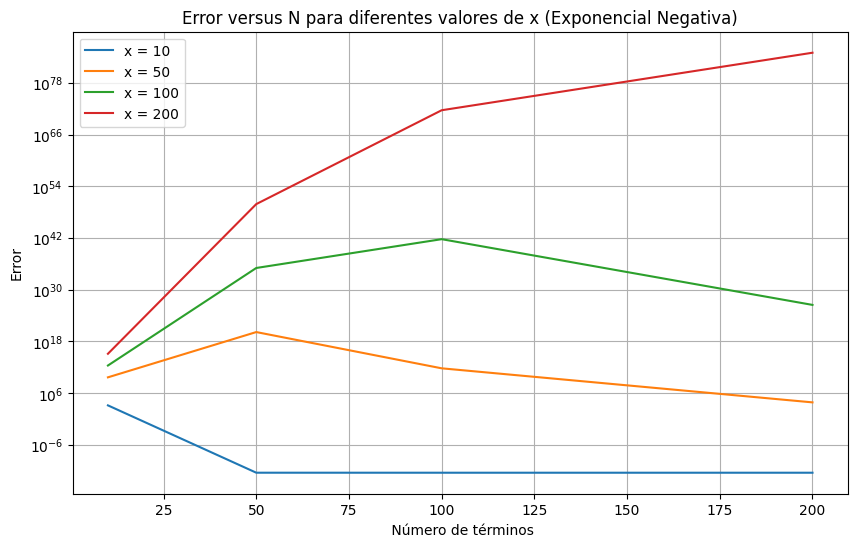

In [113]:
Valores_N = np.arange(1,21)


plt.figure(figsize=(10, 6))
for x in valores:
    error = [abs(np.exp((-1)*x) - exponencial_negativa(x, N)) for N in valores]
    plt.plot(valores, error, label=f"x = {x}")
plt.yscale("log")
plt.title("Error versus N para diferentes valores de x (Exponencial Negativa)")
plt.xlabel(" Número de términos")
plt.ylabel("Error")
plt.legend()
plt.grid()
plt.show()

# 3. Serie $S_N$

Un ejemplo de la cancelacion substractiva es en la suma de series alternantes. Considere la serie $\mathrm{S}_N$,  escrita  matematicamente de tres formas diferentes:

-
\begin{equation}
\mathrm{S}_N^{(1)} = \sum_{n = 1}^{2N} (-1)^n \frac{n}{n+1}
\end{equation}

- Sumando números pares e impares.

\begin{equation}
\mathrm{S}_N^{(2)} = -\sum_{n = 1}^{N}\frac{2n-1}{2n} + \sum_{n=1}^{N} \frac{2n}{2n+1}
\end{equation}

- Combinando las series de una forma analítica

\begin{equation}
\mathrm{S}_N^{(3)} = \sum_{n = 1}^{N}\frac{1}{2n(2n+1)}
\end{equation}



Las tres sumas $\mathrm{S}_N^{(1)}$, $\mathrm{S}_N^{(2)}$ y $\mathrm{S}_N^{(3)}$ son matemáticamente iguales, pero los resultados númericos  pueden tener diferencias.


a.  Escribir tres funciones para que realicen el cálculo de $\mathrm{S}_N^{(1)}$, $\mathrm{S}_N^{(2)}$ y $\mathrm{S}_N^{(3)}$


b. Estudiar la convergencia de la serie para los tres casos.


c. Considere  que $S_N^{(3)}$ es la solución exacta, realizar dos graficos log-log, del error relativo en función
del número de términos ($\mathrm{Log_{10}} E$ VS $\mathrm{Log_{10}} N$), para $S_N^{(1)}$ y $S_N^{(2)}$. Donde,  $$E = |(S_N^{(i)} - S_N^{(3)})/S_N^{(3)}|,$$ $i = 1, 2$. Considere valores de $N = 1\times 10^{6}$.

d. Analizar y discutir los resultados. Tenga en cuenta la discusión realizada sobre teoría de errores en la página
39 del libro [Computational Physics. ](https://www.dropbox.com/s/n06ul2r4l65khl6/Computational%20Physics%20-%20Problem%20Solving%20with%20Computers%2C%203527406263.pdf?dl=0)

In [87]:
#a
tolerancia = 1e-8

def SN_1 (a):
  N = 0
  S_ant = 0
  for n in range(1,2*a+1):
    SN_1 = (np.power(-1,n))*(n/(n+1))
    N += SN_1
    if abs(S_ant - SN_1) < tolerancia:
      break
    S_ant = SN_1
  return N

def SN_2(b):
  M = 0
  S_ant = 0
  for n in range(1,b+1):
    termino_1 = (2*n-1)/(2*n)
    termino_2 = (2*n)/(2*n+1)
    M += -termino_1 + termino_2
    if abs(S_ant - (-termino_1 + termino_2)) < tolerancia:
      break
    S_ant = (-termino_1 + termino_2)
  return M

def SN_3(c):
  L = 0
  s_ant = 0
  for n in range(1,c+1):
    SN_3 = 1/(2*n*(2*n+1))
    L += SN_3
    if abs(s_ant-SN_3) < tolerancia:
      break
    s_ant = SN_3
  return L

In [89]:
N = 10**6
print(SN_1(N))
print(SN_2(N))
print(SN_3(N))

0.3068525694401464
0.30617668722717495
0.3061766872271769


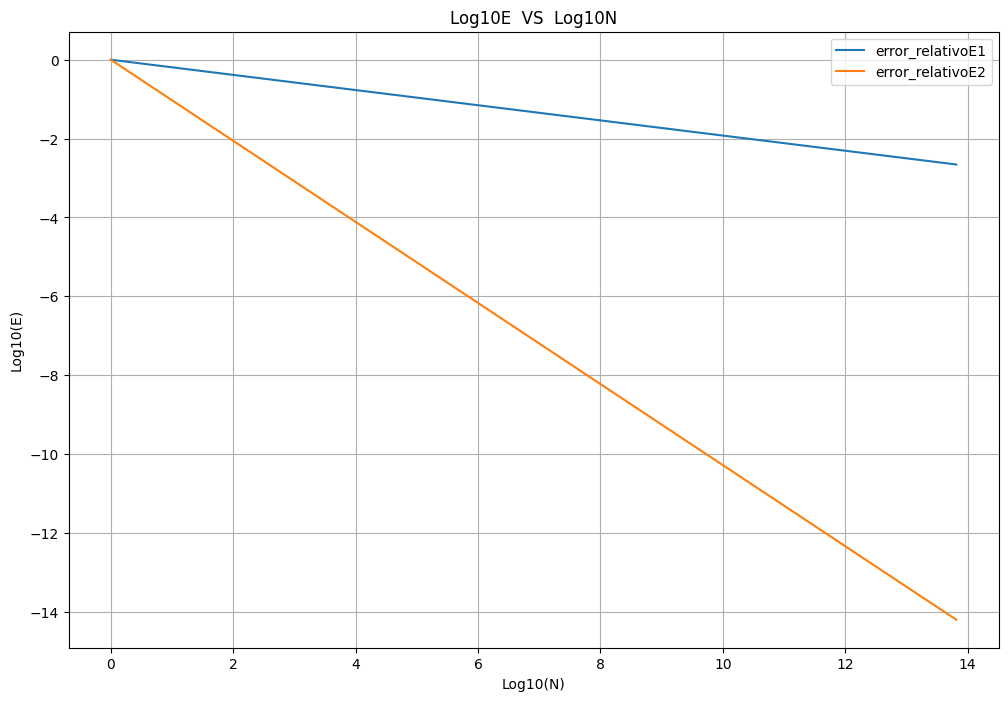

In [115]:
#c trate de hacerlo como nos mostro en su codigo pero no pude lograr de hacerlo solo me dieron un par de rectas, aun asi le escribi al correro y no recibi respuesta.
error_relativoE1 = abs((SN_1(N)-SN_3(N))/ SN_3(N))
error_relativoE2 = abs((SN_2(N)-SN_3(N))/ SN_3(N))

vector_1 = np.linspace(0,np.log10(error_relativoE1),200)
vector_2 = np.linspace(0,np.log10(error_relativoE2),200)
x = np.linspace(0,np.log(N),200)

plt.figure(figsize=(12,8))
plt.plot(x,vector_1, label = "error_relativoE1")
plt.plot(x,vector_2, label = "error_relativoE2")
plt.title("Log10E  VS  Log10N")
plt.xlabel("Log10(N)")
plt.ylabel("Log10(E)")
plt.grid(True)
plt.legend()
plt.show()